In [7]:
import pylatexenc
import matplotlib
import qiskit
from qiskit import *

In [8]:
qiskit.__version__

'2.3.0'

In [9]:
qc = QuantumCircuit(3,3)
qc.draw()

q_0: 
     
q_1: 
     
q_2: 
     
c: 3/

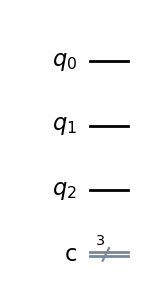

In [10]:
qc.draw('mpl')

In [11]:
qc.measure([0,1,2], [0,1,2])
qc.draw()

┌─┐      
q_0: ┤M├──────
     └╥┘┌─┐   
q_1: ─╫─┤M├───
      ║ └╥┘┌─┐
q_2: ─╫──╫─┤M├
      ║  ║ └╥┘
c: 3/═╩══╩══╩═
      0  1  2

In [12]:
qreg1 = QuantumRegister(size = 2, name = "qrg1")
qreg2 = QuantumRegister(size = 1, name = "qrg2")
creg = ClassicalRegister(1, "oldschool")

In [13]:
qc1 = QuantumCircuit(qreg1, creg, qreg2)
qc1.draw()

qrg1_0: 
             
     qrg1_1: 
             
       qrg2: 
             
oldschool: 1/

In [14]:
qc1.draw()

qrg1_0: 
             
     qrg1_1: 
             
       qrg2: 
             
oldschool: 1/

In [15]:
# QUANTUM GATES
# por defecto todos los qubits se inicializan al estado |0>

In [16]:
qc.x(0)
# aplicar una puerta X al primer quibit. Indexado habitual en Python (comienza en 0)

In [17]:
qc.draw()

┌─┐┌───┐   
q_0: ┤M├┤ X ├───
     └╥┘└┬─┬┘   
q_1: ─╫──┤M├────
      ║  └╥┘ ┌─┐
q_2: ─╫───╫──┤M├
      ║   ║  └╥┘
c: 3/═╩═══╩═══╩═
      0   1   2

In [18]:
qc = QuantumCircuit(2,2)
qc.draw()

q_0: 
     
q_1: 
     
c: 2/

In [19]:
qc.x(0)
qc.h(1)
qc.cx(0,1)
qc.measure([0,1],[0,1])
qc.draw()

┌───┐     ┌─┐   
q_0: ┤ X ├──■──┤M├───
     ├───┤┌─┴─┐└╥┘┌─┐
q_1: ┤ H ├┤ X ├─╫─┤M├
     └───┘└───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1

In [20]:
# CUANDO SE EJECUTA UN BLQUE DE CODIGO SIN LA SEMILLA DEL CIRCUITO, SE AÑADE A LO ANTERIOR -> 
# SE PUEDE GENERAR UN CIRCUITO QUE NO ES EL QUE SE BUSCA, MÁS COMPONENTES DE LO NECESARIO

In [21]:
# HELLO WORLD EXAMPLO ON A TWO QUBIT BELL STATE

In [22]:
hqc = QuantumCircuit(2)
hqc.h(0)
hqc.cx(0,1)
hqc.measure_all()
hqc.draw()

┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1

In [23]:
from qiskit.quantum_info import Pauli

ZZ = Pauli('ZZ')
ZI = Pauli('ZI')
IZ = Pauli('IZ')
XX = Pauli('XX')
XI = Pauli('XI')
IX = Pauli('IX')

observables = [ZZ, ZI, IZ, XX, XI, IX]

In [ ]:
#EJECUTAR EN EL BACKEND (SIMULACION)

from qiskit_aer import AerSimulator
sim = AerSimulator()
compiled = transpile(hqc,sim)
job = sim.run(compiled, shots = 1024)
result = job.result()
counts = result.get_counts()